In [1]:
import numpy as np
import tensorflow as tf

# ============================================================
# 1. Create the XOR Dataset
# ============================================================

X = tf.constant([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=tf.float32)

y = tf.constant([
    [0],
    [1],
    [1],
    [0]
], dtype=tf.float32)

# ============================================================
# 2. Define Network Architecture
# ============================================================

input_neurons = 2
hidden_neurons = 4
output_neurons = 1

# ============================================================
# 3. Initialize Weights and Biases
# ============================================================

W1 = tf.Variable(
    tf.random.normal(
        [input_neurons, hidden_neurons],
        stddev=0.5
    )
)

b1 = tf.Variable(
    tf.zeros([hidden_neurons])
)

W2 = tf.Variable(
    tf.random.normal(
        [hidden_neurons, output_neurons],
        stddev=0.5
    )
)

b2 = tf.Variable(
    tf.zeros([output_neurons])
)

# ============================================================
# 4. Display Network Parameters
# ============================================================

print("TensorFlow Low-Level MLP")
print("========================")

print("\nInput neurons:", input_neurons)
print("Hidden neurons:", hidden_neurons)
print("Output neurons:", output_neurons)

print("\nW1 shape:", W1.shape)
print("b1 shape:", b1.shape)

print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

TensorFlow Low-Level MLP

Input neurons: 2
Hidden neurons: 4
Output neurons: 1

W1 shape: (2, 4)
b1 shape: (4,)
W2 shape: (4, 1)
b2 shape: (1,)


In [2]:
# ============================================================
# 5. Define the Forward Pass
# ============================================================

def forward_pass(X):
    # Hidden layer calculation
    hidden_input = tf.matmul(X, W1) + b1

    # Tanh activation
    hidden_output = tf.tanh(hidden_input)

    # Output layer calculation
    output_input = tf.matmul(hidden_output, W2) + b2

    # Sigmoid activation
    output = tf.sigmoid(output_input)

    return hidden_output, output


# ============================================================
# 6. Perform Forward Pass
# ============================================================

hidden_output, predictions = forward_pass(X)

print("\nForward Pass Results")
print("====================")

print("\nHidden Layer Output:")
print(hidden_output.numpy())

print("\nOutput Layer Predictions:")
print(predictions.numpy())


Forward Pass Results

Hidden Layer Output:
[[ 0.          0.          0.          0.        ]
 [ 0.43128887  0.5755473  -0.39603528  0.5609126 ]
 [ 0.7766509  -0.34714153  0.11383646  0.02445192]
 [ 0.90485036  0.28543448 -0.29552191  0.5774447 ]]

Output Layer Predictions:
[[0.5       ]
 [0.55684584]
 [0.52731425]
 [0.5735004 ]]


In [4]:
# ============================================================
# 7. Define Loss Function and Optimizer
# ============================================================

loss_function = tf.keras.losses.BinaryCrossentropy()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.01
)


# ============================================================
# 8. Training Step
# ============================================================

def train_step(X, y):

    with tf.GradientTape() as tape:

        # Forward pass
        hidden_input = tf.matmul(X, W1) + b1
        hidden_output = tf.tanh(hidden_input)

        output_input = tf.matmul(hidden_output, W2) + b2
        predictions = tf.sigmoid(output_input)

        # Calculate Binary Cross-Entropy loss
        loss = loss_function(y, predictions)

    # Calculate gradients
    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )

    # Update weights and biases
    optimizer.apply_gradients(
        zip(
            gradients,
            [W1, b1, W2, b2]
        )
    )

    return loss

In [5]:
# ============================================================
# 10. Final Predictions
# ============================================================

# Forward pass after training
hidden_input = tf.matmul(X, W1) + b1
hidden_output = tf.tanh(hidden_input)

output_input = tf.matmul(hidden_output, W2) + b2
predictions = tf.sigmoid(output_input)

# Convert probabilities to binary predictions
binary_predictions = tf.cast(
    predictions >= 0.5,
    tf.float32
)

# ============================================================
# 11. Calculate Final Accuracy
# ============================================================

correct_predictions = tf.equal(
    binary_predictions,
    y
)

accuracy = tf.reduce_mean(
    tf.cast(correct_predictions, tf.float32)
)

# ============================================================
# 12. Display Results
# ============================================================

print("\nFinal XOR Predictions")
print("=====================")

print("\nPredicted Probabilities:")
print(predictions.numpy())

print("\nBinary Predictions:")
print(binary_predictions.numpy().astype(int))

print("\nExpected Outputs:")
print(y.numpy().astype(int))

print("\nFinal Accuracy:",
      accuracy.numpy() * 100,
      "%")


Final XOR Predictions

Predicted Probabilities:
[[0.5       ]
 [0.55684584]
 [0.52731425]
 [0.5735004 ]]

Binary Predictions:
[[1]
 [1]
 [1]
 [1]]

Expected Outputs:
[[0]
 [1]
 [1]
 [0]]

Final Accuracy: 50.0 %


In [6]:
# ============================================================
# TensorFlow Low-Level MLP - Complete Training
# ============================================================

import numpy as np
import tensorflow as tf

# ------------------------------------------------------------
# 1. XOR Dataset
# ------------------------------------------------------------

X = tf.constant([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=tf.float32)

y = tf.constant([
    [0],
    [1],
    [1],
    [0]
], dtype=tf.float32)


# ------------------------------------------------------------
# 2. Network Architecture
# ------------------------------------------------------------

input_neurons = 2
hidden_neurons = 4
output_neurons = 1


# ------------------------------------------------------------
# 3. Initialize Weights and Biases
# ------------------------------------------------------------

W1 = tf.Variable(
    tf.random.normal(
        [input_neurons, hidden_neurons],
        stddev=0.5
    )
)

b1 = tf.Variable(
    tf.zeros([hidden_neurons])
)

W2 = tf.Variable(
    tf.random.normal(
        [hidden_neurons, output_neurons],
        stddev=0.5
    )
)

b2 = tf.Variable(
    tf.zeros([output_neurons])
)


# ------------------------------------------------------------
# 4. Loss Function and Optimizer
# ------------------------------------------------------------

loss_function = tf.keras.losses.BinaryCrossentropy()

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.01
)


# ------------------------------------------------------------
# 5. Forward Pass
# ------------------------------------------------------------

def forward_pass(X):

    hidden_input = tf.matmul(X, W1) + b1

    hidden_output = tf.tanh(hidden_input)

    output_input = tf.matmul(hidden_output, W2) + b2

    output = tf.sigmoid(output_input)

    return output


# ------------------------------------------------------------
# 6. Training Step
# ------------------------------------------------------------

def train_step(X, y):

    with tf.GradientTape() as tape:

        predictions = forward_pass(X)

        loss = loss_function(y, predictions)

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            [W1, b1, W2, b2]
        )
    )

    return loss


# ------------------------------------------------------------
# 7. Train the Model
# ------------------------------------------------------------

epochs = 1000

loss_history = []

print("Training the MLP")
print("================")

for epoch in range(epochs):

    loss = train_step(X, y)

    loss_history.append(loss.numpy())

    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch {epoch + 1}/{epochs} - "
            f"Loss: {loss.numpy():.6f}"
        )


print("\nTraining completed.")


# ------------------------------------------------------------
# 8. Final Predictions
# ------------------------------------------------------------

predictions = forward_pass(X)

binary_predictions = tf.cast(
    predictions >= 0.5,
    tf.float32
)


# ------------------------------------------------------------
# 9. Calculate Accuracy
# ------------------------------------------------------------

correct_predictions = tf.equal(
    binary_predictions,
    y
)

accuracy = tf.reduce_mean(
    tf.cast(
        correct_predictions,
        tf.float32
    )
)


# ------------------------------------------------------------
# 10. Display Final Results
# ------------------------------------------------------------

print("\nFinal XOR Predictions")
print("=====================")

print("\nPredicted Probabilities:")
print(predictions.numpy())

print("\nBinary Predictions:")
print(binary_predictions.numpy().astype(int))

print("\nExpected Outputs:")
print(y.numpy().astype(int))

print(
    "\nFinal Accuracy:",
    accuracy.numpy() * 100,
    "%"
)

Training the MLP
Epoch 100/1000 - Loss: 0.500942
Epoch 200/1000 - Loss: 0.080146
Epoch 300/1000 - Loss: 0.024147
Epoch 400/1000 - Loss: 0.012701
Epoch 500/1000 - Loss: 0.008172
Epoch 600/1000 - Loss: 0.005818
Epoch 700/1000 - Loss: 0.004403
Epoch 800/1000 - Loss: 0.003471
Epoch 900/1000 - Loss: 0.002819
Epoch 1000/1000 - Loss: 0.002340

Training completed.

Final XOR Predictions

Predicted Probabilities:
[[0.00264482]
 [0.99794364]
 [0.9974583 ]
 [0.00209148]]

Binary Predictions:
[[0]
 [1]
 [1]
 [0]]

Expected Outputs:
[[0]
 [1]
 [1]
 [0]]

Final Accuracy: 100.0 %


In [7]:
# ============================================================
# Clean Final XOR Results
# ============================================================

print("FINAL XOR RESULTS")
print("=================")

print("\nInput    Expected    Predicted Probability    Predicted")
print("--------------------------------------------------------")

for i in range(4):
    print(
        f"{X.numpy()[i].astype(int)}"
        f"       {int(y.numpy()[i][0])}"
        f"          {predictions.numpy()[i][0]:.6f}"
        f"                  {int(binary_predictions.numpy()[i][0])}"
    )

print("\nFinal Accuracy:", accuracy.numpy() * 100, "%")

FINAL XOR RESULTS

Input    Expected    Predicted Probability    Predicted
--------------------------------------------------------
[0 0]       0          0.002645                  0
[0 1]       1          0.997944                  1
[1 0]       1          0.997458                  1
[1 1]       0          0.002091                  0

Final Accuracy: 100.0 %


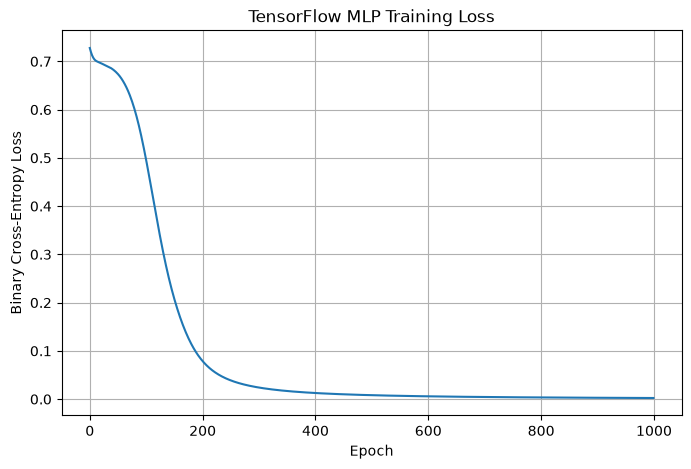

In [8]:
# ============================================================
# TensorFlow Training Loss Curve
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.title("TensorFlow MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)

plt.show()